As of Feb 2025, Python 3.13 (default in BAS since this month) is not supported by `tensorflow` package, so conda to be used.

## Preview the machine-generated images of pets

You will be working on a set of machine-generated images of the most popular (again, accordingly to the GenAI) breeds of cats and dogs. Images are stored in the folder [./pets/](./pets/) 

In [1]:
from PIL import Image as PILImage
from IPython.display import display

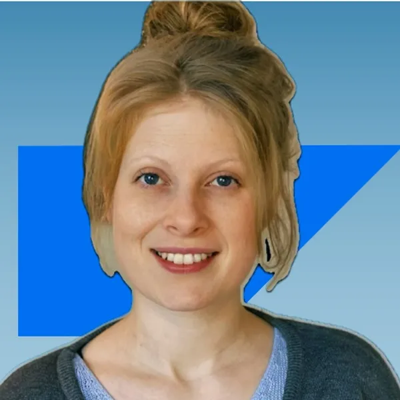

In [4]:
dir_images='./images/'

img = PILImage.open(dir_images+'c6b8a044674f641322e0fc6ed8152c6685d7b479030d6585b93f43aab760e53f.webp')
display(img.resize((400, 400)))

## Get image [embeddings](https://help.sap.com/docs/hana-cloud-database/sap-hana-cloud-sap-hana-database-vector-engine-guide/vectors-vector-embeddings-and-metrics)

You will use `ResNet50V2` model from https://keras.io/api/applications/#available-models to get embeddings of the images.

Ignore possible information `I` and warning `W` messages from the first `tensorflow` import below.

In [5]:
from tensorflow.keras.applications.resnet_v2 import ResNet50V2, preprocess_input
from tensorflow.keras.preprocessing import image as tf_image

import pandas as pd
import numpy as np
# from tqdm.auto import tqdm

2026-07-13 20:56:59.116249: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-13 20:56:59.596412: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [9]:
mymodel = ResNet50V2(include_top=False, weights='imagenet', pooling='avg')

The model ResNet50V2 will be downloaded during the first instantiation to the folder `~/.keras/models/`.

In [6]:
!ls -lh ~/.keras/models/

total 91M
-rw-rw-r-- 1 user group 91M Feb 27  2025 resnet50v2_weights_tf_dim_ordering_tf_kernels_notop.h5


To speed up processing a bit you will reduce the size of the images by half `1024//2`. Please note the use of `//` to have integer number as a result.

In [7]:
#Function to get embeddings

def get_image_embedding(model, img_path):
    img = tf_image.load_img(img_path, target_size=(1024//2, 1024//2))
    x = tf_image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    embeddings = model.predict(x)  
    result = pd.DataFrame(embeddings[0]).T
    return result

Get embeddings for all images in the source directory and store them in the `embedding_df` Pandas DataFrame for now.

In [10]:
import os
import pandas as pd

dir_images = './images/'

path_images = os.listdir(dir_images)
embedding_df = pd.DataFrame()
for current_img in path_images:
    curr_df = get_image_embedding(model=mymodel, img_path=dir_images + current_img)
    curr_df['image'] = current_img
    embedding_df = pd.concat([embedding_df, curr_df], ignore_index=True)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [11]:
# Check one of the generated embeddings
display(embedding_df.iloc[0])

# Note 2048 fileds with real numbers for dimensions from 0 to 2047, plus the file name in the last field.

0                                                 0.098445
1                                                      0.0
2                                                 0.285479
3                                                 0.081719
4                                                 0.010107
                               ...                        
2044                                              0.139599
2045                                              0.643566
2046                                              0.068502
2047                                              0.005145
image    5a3abdb7e74b90aa1f1a2b37baee628d884624adb85f59...
Name: 0, Length: 2049, dtype: object

In [12]:
import pickle

# # Open a file in binary write mode
with open('/tmp/image_embeddings.pkl', 'wb') as file:
    # Serialize the list and write it to the file
    pickle.dump(embedding_df, file)

In [13]:
!ls -la /tmp/image_embeddings.pkl

-rw-r--r-- 1 user group 832949 Jul 13 20:58 /tmp/image_embeddings.pkl


> Switch to virtual env now to load to HANA db.

In [1]:
import pickle

# Open the file in binary read mode
with open('/tmp/image_embeddings.pkl', 'rb') as file:
    # Deserialize the list from the file
    embedding_df = pickle.load(file)

print(len(embedding_df))

100


## Load the model into SAP HANA's Vector Engine

In [4]:
%run "../01-check_setup.ipynb"

SAP HANA Client for Python: 2.28.26031701
Using the dot-env file /home/user/projects/hana-ai-ve-kg-codejam/.env
Connected to SAP HANA db version 4.00.000.00.1783512515 (fa/CE2026.14) 
at c5889dd5-e0f6-4930-8408-94d53ca61dbf.hna0.prod-us10.hanacloud.ondemand.com:443 as CODEJAMHANAAI00
Current time on the SAP HANA server: 2026-07-13 21:01:34.544000


## Upload into your SAP HANA database

...similarly to how you uploaded word vectors during the Week 2 exercise.

In [5]:
source_table="CODECONNECT_IMAGES"
source_schema="VECTORS"

In [26]:
myconn.connection.setautocommit(True)
mycursor = myconn.connection.cursor()

try:
    mycursor.execute(f'DROP TABLE "{source_schema}"."{source_table}"')
    myconn.connection.commit()

except Exception as e:
    # Handle any exceptions and possibly rollback the transaction
    myconn.connection.rollback()
    print("An error occurred:", e)

The table `IMAGES` will store:
- a file name in `"IMAGE_NAME"`
- a breed name in `"NAME"`
- an **i**mage embedding (or **v**ector) in `"IV"`
- a Base64-encoded image of a pet in `"IMAGE"`

In [27]:
myconn.create_table(
    source_table, schema=source_schema,
    table_structure={
        "IMAGE_NAME": "NVARCHAR(128)", 
        "NAME": "NVARCHAR(128)", 
        "IV": "REAL_VECTOR(2048)",
        "IMAGE": "NCLOB"
        }
    )

## Get image Base64 encodings to be stored in the database table 

In [8]:
from io import BytesIO
import base64

In [9]:
# Function to open and encode an image to Base64
def get_image_encoding(image_path, size=(400, 400)):
    img_resized = PILImage.open(image_path).resize(size)
    buffer = BytesIO()
    img_resized.save(buffer, format="WEBP")
    encoded_img = base64.b64encode(buffer.getvalue()).decode('utf-8')
    return encoded_img


In the next cell, prepare the list of records `myrecords_to_insert` to be inserted into the database.

Each record has 4 fields with:
- a file name: `[myrow[-1:][0]`
- a breed name derived from a file name: `myrow[-1:][0].split('.')[0].split('_')[1]`
- image encoding: `get_image_encoding(dir_images+myrow[-1:][0])` for an image read from the file name
- a string representation of a vector embedding `str(myrow[:-1])`

In [10]:
from PIL import Image as PILImage
from IPython.display import display

In [13]:
embedding_df.shape

(100, 2049)

In [15]:
dir_images = './images/'
my_embeddings=embedding_df.values.tolist()


In [22]:
my_embeddings[0][-1]

'5a3abdb7e74b90aa1f1a2b37baee628d884624adb85f599427327eecd537142a.jpg'

In [23]:
%%time

myrecords_to_insert=[
    [myrow[-1], #file name
    myrow[-1].split('.')[0], 
    get_image_encoding(dir_images+myrow[-1]), 
    str(myrow[:-1])]
    for myrow in my_embeddings]

CPU times: user 2.16 s, sys: 7.96 ms, total: 2.17 s
Wall time: 2.3 s


In [24]:
#Display one of the records to see its all 4 fields
display(myrecords_to_insert[0])

['5a3abdb7e74b90aa1f1a2b37baee628d884624adb85f599427327eecd537142a.jpg',
 '5a3abdb7e74b90aa1f1a2b37baee628d884624adb85f599427327eecd537142a',
 'UklGRnYYAABXRUJQVlA4IGoYAADwywCdASqQAZABPm0ylEckJaahKTVKWNANiWduzoZklQsj18psZOv/G/3IvjDrhPpI7fBS8a7U82S9umTOoEoEpech5X9BbuJxumTdRtsl7dMmZmvOu+f9ySKWiiQ8CXJsA7LLyWq/ynRxESUHEMuZiXCTAuDbZGFc1Ekl88P4zKk1nks9+yjO0FdxHcnLIjNZP7GB7uhKfMxlOPC97foMlw7lJgYrZynWTG2yXt0ybkUx/KLwYihsrRPcVu/sZnKGmE9MKiY88Gbi78tFIFhox6K1+R7xNnT1RHJKhenp8AxFHEOpAMKOsm42rd7YtkI6yhlE6Mv0MQfeYrbDcRY6jnzqyvPKIYJwyJZRWjnx+WtpBQpmsxQJktg1gUBIg8/eOybqNtkZtLRKy+BySDySiHE+3nXPrsfy9/IaIHMNZQ79p9tvXeDs6agDfKdHGn1dXikTfwDw1MR5D7OsnMmoDx6XjEQfHro5QV5fb7/o6ybqNrLZaTLHfyALjUvx+xLlUxOGSovfW4Ss6VfUmlCt0tVCcBqCVqRioUAD2A0FBexCz7DHFFsPpT5HmANy1xVpMBAkwLg2qaaRXVnfazGJH6uZ+V28TQ237nM99c2Cwguk/TW+4J2VbcLJRC3PMzc3iLE2ez4nlU9JnU/w45Ysc+iBy4Nskb2MxierXKV7rlx1sfEnAV7gq7Djcw/3VURNPW98u4Vyx084VYwAneEeyc5rH9TWfTwxycFI71FgRxIYvi9JIx7Mj7TbzqacijrJrX+ZQcrJ+wyYIdlkIJcLPRoSfvFlbdv9g19AE3//jVl7IkJl+4znuwcFnbTa

In [28]:
%%time
myconn.connection.setautocommit(False)
cursor = myconn.connection.cursor()

try:
    mycursor.execute(f'TRUNCATE TABLE "{source_schema}"."{source_table}"')
    # Use the executemany method to insert the data
    cursor.executemany(
        f'''INSERT INTO "{source_schema}"."{source_table}" ("IMAGE_NAME", "NAME", "IMAGE", "IV") VALUES (?, ?, ?, TO_REAL_VECTOR(?))''', 
        myrecords_to_insert
    )

except Exception as e:
    # Handle any exceptions and possibly rollback the transaction
    myconn.connection.rollback()
    print("An error occurred:", e)

CPU times: user 26.2 ms, sys: 164 μs, total: 26.4 ms
Wall time: 132 ms


In [29]:
%%time
try:
    # Commit the transaction to save the changes
    myconn.connection.commit()

finally:
    # Close the cursor and the connection when done
    cursor.close()

CPU times: user 791 μs, sys: 57 μs, total: 848 μs
Wall time: 6.03 ms


## Check data in the database table

In [30]:
## Check the size of the table in the database
print(f"Number of records in the table {source_table}: {myconn.table(table=source_table, schema=source_schema).count()}")

Number of records in the table CODECONNECT_IMAGES: 100


In [31]:
## Display a record for one of the entries
word='5a3abdb7e74b90aa1f1a2b37baee628d884624adb85f599427327eecd537142a'

sql = f'''
SELECT "A".* FROM "{source_schema}"."{source_table}" AS "A"
WHERE "A"."NAME"='{word}'
'''

hdf = myconn.sql(sql)
print(hdf.select_statement)
hdf.head(3).collect()


SELECT "A".* FROM "VECTORS"."CODECONNECT_IMAGES" AS "A"
WHERE "A"."NAME"='5a3abdb7e74b90aa1f1a2b37baee628d884624adb85f599427327eecd537142a'


,IMAGE_NAME,NAME,IV,IMAGE
0,5a3abdb7e74b90aa1f1a2b37baee628d884624adb85f59...,5a3abdb7e74b90aa1f1a2b37baee628d884624adb85f59...,"[0, 8, 0, 0, 130, 157, 201, 61, 0, 0, 0, 0, 82...",UklGRnYYAABXRUJQVlA4IGoYAADwywCdASqQAZABPm0ylE...


Note that the `"IV"` column is binary and can be represented in different formats in different database client tools, as mentioned by Dirk O. in his comment: https://community.sap.com/t5/application-development-discussions/questions-re-quot-multi-model-with-sap-hana-cloud-quot-developer-challenge/m-p/13732043/highlight/true#M2028526

It is only when transofrmed to the string with [`TO_NVARCHAR()`](https://help.sap.com/docs/hana-cloud-database/sap-hana-cloud-sap-hana-database-vector-engine-guide/to-nvarchar-function-data-type-conversion?version=2024_1_QRC&locale=en-US) then you can see its vector representation.

In [32]:
## Display a record for one of the entries
word='5a3abdb7e74b90aa1f1a2b37baee628d884624adb85f599427327eecd537142a'

sql = f'''
SELECT TO_NVARCHAR("IV") FROM "{source_schema}"."{source_table}" AS "A"
WHERE "A"."NAME"='{word}'
'''

hdf = myconn.sql(sql)
print(hdf.select_statement)

__import__("pandas").set_option('display.max_colwidth', 180)
display(hdf.head(3).collect())

__import__("pandas").reset_option('display.max_colwidth')


SELECT TO_NVARCHAR("IV") FROM "VECTORS"."CODECONNECT_IMAGES" AS "A"
WHERE "A"."NAME"='5a3abdb7e74b90aa1f1a2b37baee628d884624adb85f599427327eecd537142a'


,TO_NVARCHAR(IV)
0,"[0.09844495,0,0.28547913,0.08171876,0.010106699,0,0.11186664,0.13456494,0.13280739,0,0,0,0.009955509,0.50071543,0.025302943,0,0,0.57229483,0,0.11328822,0,0.0059546586,0.0887381..."
